# Feature Selection FPT

In [1]:
stock_code = "FPT"

In [2]:
stock_code = str.lower(stock_code)

## Import libraries

In [3]:
import os
import sys
import pandas as pd

# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from feature_selector.feature_selector import (
    FeatureSelector,
)
from utils.constants import *
from utils.enums import *
from utils.utils import cast_columns_to_float
from dtos.tabular_database_driver_dtos.tabular_database_driver_dtos import *
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from matplotlib.pylab import ceil

## Initialize the Logger

In [4]:
my_logger = Logger(
    file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/{stock_code}_feature_selection"
)

## List all FeatureSelectorType

In [5]:
print([member.name for member in FeatureSelectorType])

['XGB_REGRESSOR', 'LASSO', 'ELASTIC_NET', 'XGB_SHAP']


## Initialize the Database Driver

In [6]:
database_driver = PostgreSQLDriver(logger=my_logger)

connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

database_driver.connect(connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

## Parameters

In [7]:
output_column_name = "close"

In [8]:
train_ratio = DEFAULT_TRAIN_RATIO
train_window_size = DEFAULT_TRAIN_WINDOW_SIZE
validation_window_size = DEFAULT_VALIDATION_WINDOW_SIZE
test_window_size = DEFAULT_TEST_WINDOW_SIZE

## Load data

In [9]:
df = database_driver.select(
    schema_name=Schema.ENTERPRISE.value,
    table_name=f"unified_{stock_code}",
)
df = cast_columns_to_float(df)

In [10]:
df

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,eom_20,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10
0,2007-10-04,7.562049,17.882344,2406.138387,115.831987,97.292581,20.176133,28.639014,13.919893,597.898599,...,0.063974,0.013752,1.572394e+03,705.695191,-0.144824,-0.155760,0.010936,2089.084721,1435.104345,-46651.229284
1,2007-10-05,7.561311,17.894814,2417.355484,115.912763,97.763226,20.190203,28.658985,13.929600,598.315544,...,0.049712,0.007764,1.497772e+03,705.695191,-0.140902,-0.152788,0.011886,1647.136005,1465.394582,-84138.628711
2,2007-10-08,7.559098,17.932225,2451.006774,116.155089,99.175161,20.232413,28.718900,13.958721,599.566378,...,0.045432,0.004934,1.497772e+03,693.034370,-0.136974,-0.149626,0.012651,1301.166457,1441.933421,-89210.966379
3,2007-10-09,7.558361,17.944695,2462.223871,116.235864,99.645806,20.246483,28.738871,13.968428,599.983322,...,0.056099,0.007278,1.497772e+03,725.918651,-0.132675,-0.146235,0.013560,1428.415956,1440.002355,-36784.961064
4,2007-10-10,7.557623,17.957165,2473.440968,116.316640,100.116452,20.260552,28.758842,13.978135,600.400267,...,0.063313,0.016438,1.497772e+03,725.918651,-0.128074,-0.142603,0.014529,1341.339431,1425.907652,-18331.361208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4222,2025-06-20,7.846813,106.966667,936.533333,579.360000,72.863333,315.580000,222.863333,224.926667,2770.786667,...,-0.000486,0.029006,1.107480e+08,0.092445,0.378134,0.406903,-0.028769,16922.373760,15488.360659,-109085.483770
4223,2025-06-23,7.880769,106.676667,927.445333,586.434000,71.482333,302.707000,222.304333,227.240667,2738.915667,...,-0.023103,0.010795,1.105571e+08,0.092445,0.373407,0.400204,-0.026797,14826.318080,15393.783147,-314249.940594
4224,2025-06-25,7.903407,106.483333,921.386667,591.150000,70.561667,294.125000,221.931667,228.783333,2717.668333,...,0.041679,0.020217,1.117019e+08,0.092445,0.369833,0.394129,-0.024296,17034.466762,15628.166521,736327.896353
4225,2025-06-26,7.914725,106.386667,918.357333,593.508000,70.101333,289.834000,221.745333,229.554667,2707.044667,...,0.025493,0.016449,1.117019e+08,0.092366,0.365828,0.388469,-0.022641,15114.806572,15554.829385,307389.706147


In [11]:
def _find_split_index(
    dataframe: pd.DataFrame,
    train_window_size: int,
    validation_window_size: int,
    test_window_size: int,
    train_ratio: float,
) -> int:
    """
    Determine the index to split the dataframe into training and testing portions
    for time series forecasting with explicit validation and test windows.

    Rules:
    1. Split based on `train_ratio`.
    2. Ensure there's enough data left for both validation and test windows.
    3. Ensure the split index aligns cleanly with test window size for consistency.
    """

    # --- Sort chronologically if 'date' column exists ---
    if "date" in dataframe.columns:
        dataframe = dataframe.sort_values("date").reset_index(drop=True)
    else:
        dataframe = dataframe.reset_index(drop=True)

    total_len = len(dataframe)
    min_required = train_window_size + validation_window_size + test_window_size

    if total_len <= min_required:
        raise ValueError(
            f"Data length ({total_len}) must exceed total required window size "
            f"({min_required})."
        )

    # --- Initial rough split ---
    split_index = ceil(total_len * train_ratio)

    # --- Adjust to ensure validation & test windows fit after split ---
    split_index = min(
        split_index, total_len - (validation_window_size + test_window_size)
    )

    # --- Align to multiple of test_window_size (optional smoothing) ---
    remainder = split_index % test_window_size
    if remainder != 0:
        split_index -= remainder

    # --- Guard against invalid split ---
    if split_index <= train_window_size or split_index >= total_len:
        raise ValueError(
            f"Adjusted split_index ({split_index}) invalid for data length {total_len}"
        )

    return int(split_index)


split_index = _find_split_index(
    dataframe=df,
    train_window_size=train_window_size,
    validation_window_size=validation_window_size,
    test_window_size=test_window_size,
    train_ratio=train_ratio,
)

split_index

3780

In [12]:
# --- Split train/test ---
train = df.iloc[:split_index].reset_index(drop=True)
test = df.iloc[split_index:].reset_index(drop=True)

In [13]:
train

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,eom_20,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10
0,2007-10-04,7.562049,17.882344,2406.138387,115.831987,97.292581,20.176133,28.639014,13.919893,597.898599,...,0.063974,0.013752,1.572394e+03,705.695191,-0.144824,-0.155760,0.010936,2089.084721,1435.104345,-46651.229284
1,2007-10-05,7.561311,17.894814,2417.355484,115.912763,97.763226,20.190203,28.658985,13.929600,598.315544,...,0.049712,0.007764,1.497772e+03,705.695191,-0.140902,-0.152788,0.011886,1647.136005,1465.394582,-84138.628711
2,2007-10-08,7.559098,17.932225,2451.006774,116.155089,99.175161,20.232413,28.718900,13.958721,599.566378,...,0.045432,0.004934,1.497772e+03,693.034370,-0.136974,-0.149626,0.012651,1301.166457,1441.933421,-89210.966379
3,2007-10-09,7.558361,17.944695,2462.223871,116.235864,99.645806,20.246483,28.738871,13.968428,599.983322,...,0.056099,0.007278,1.497772e+03,725.918651,-0.132675,-0.146235,0.013560,1428.415956,1440.002355,-36784.961064
4,2007-10-10,7.557623,17.957165,2473.440968,116.316640,100.116452,20.260552,28.758842,13.978135,600.400267,...,0.063313,0.016438,1.497772e+03,725.918651,-0.128074,-0.142603,0.014529,1341.339431,1425.907652,-18331.361208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3775,2023-08-14,4.722065,90.122522,790.967742,490.322581,53.645161,200.000000,165.161290,226.774194,2932.258065,...,0.091713,0.218405,3.260996e+07,0.187735,0.076655,0.076347,0.000308,-1122.249022,263.243876,52530.588075
3776,2023-08-15,4.735000,90.134992,790.322581,496.774194,53.548387,200.000000,168.387097,227.258065,2927.419355,...,0.115135,0.225604,3.316270e+07,0.187735,0.076981,0.076474,0.000507,-7.134362,224.618414,66581.223420
3777,2023-08-16,4.747935,90.147462,789.677419,503.225806,53.451613,200.000000,171.612903,227.741935,2922.580645,...,0.140758,0.242073,3.359693e+07,0.187735,0.078449,0.076869,0.001580,1115.046794,351.822468,183416.260432
3778,2023-08-17,4.760870,90.159933,789.032258,509.677419,53.354839,200.000000,174.838710,228.225806,2917.741935,...,0.128611,0.254161,3.395225e+07,0.187735,0.081727,0.077841,0.003886,2834.540965,706.496539,575804.853708


In [14]:
test

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,eom_20,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10
0,2023-08-21,4.812609,90.209814,786.451613,535.483871,52.967742,200.000,187.741935,230.161290,2898.387097,...,0.106508,0.249624,3.375488e+07,0.188613,0.091771,0.082059,0.009711,-774.648735,232.962292,285591.659508
1,2023-08-22,4.825543,90.222284,785.806452,541.935484,52.870968,200.000,190.967742,230.645161,2893.548387,...,0.032653,0.229224,3.375488e+07,0.189931,0.096538,0.084955,0.011583,-2969.570214,-224.542352,-193771.195238
2,2023-08-23,4.838478,90.234754,785.161290,548.387097,52.774194,200.000,194.193548,231.129032,2888.709677,...,0.062097,0.248592,3.375488e+07,0.189931,0.100338,0.088032,0.012306,-2152.520722,-499.967833,-334630.416871
3,2023-08-24,4.851413,90.247225,784.516129,554.838710,52.677419,200.000,197.419355,231.612903,2883.870968,...,0.084969,0.270314,3.553286e+07,0.189931,0.106847,0.091795,0.015052,4273.550498,181.963357,413099.639864
4,2023-08-25,4.864348,90.259695,783.870968,561.290323,52.580645,200.000,200.645161,232.096774,2879.032258,...,0.124759,0.286168,3.553286e+07,0.191197,0.113236,0.096083,0.017153,4946.225565,862.572244,232745.552531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442,2025-06-20,7.846813,106.966667,936.533333,579.360000,72.863333,315.580,222.863333,224.926667,2770.786667,...,-0.000486,0.029006,1.107480e+08,0.092445,0.378134,0.406903,-0.028769,16922.373760,15488.360659,-109085.483770
443,2025-06-23,7.880769,106.676667,927.445333,586.434000,71.482333,302.707,222.304333,227.240667,2738.915667,...,-0.023103,0.010795,1.105571e+08,0.092445,0.373407,0.400204,-0.026797,14826.318080,15393.783147,-314249.940594
444,2025-06-25,7.903407,106.483333,921.386667,591.150000,70.561667,294.125,221.931667,228.783333,2717.668333,...,0.041679,0.020217,1.117019e+08,0.092445,0.369833,0.394129,-0.024296,17034.466762,15628.166521,736327.896353
445,2025-06-26,7.914725,106.386667,918.357333,593.508000,70.101333,289.834,221.745333,229.554667,2707.044667,...,0.025493,0.016449,1.117019e+08,0.092366,0.365828,0.388469,-0.022641,15114.806572,15554.829385,307389.706147


In [15]:
train = train.drop(columns=["date"])

In [16]:
train

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_20,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10
0,7.562049,17.882344,2406.138387,115.831987,97.292581,20.176133,28.639014,13.919893,597.898599,939.485161,...,0.063974,0.013752,1.572394e+03,705.695191,-0.144824,-0.155760,0.010936,2089.084721,1435.104345,-46651.229284
1,7.561311,17.894814,2417.355484,115.912763,97.763226,20.190203,28.658985,13.929600,598.315544,940.726452,...,0.049712,0.007764,1.497772e+03,705.695191,-0.140902,-0.152788,0.011886,1647.136005,1465.394582,-84138.628711
2,7.559098,17.932225,2451.006774,116.155089,99.175161,20.232413,28.718900,13.958721,599.566378,944.450323,...,0.045432,0.004934,1.497772e+03,693.034370,-0.136974,-0.149626,0.012651,1301.166457,1441.933421,-89210.966379
3,7.558361,17.944695,2462.223871,116.235864,99.645806,20.246483,28.738871,13.968428,599.983322,945.691613,...,0.056099,0.007278,1.497772e+03,725.918651,-0.132675,-0.146235,0.013560,1428.415956,1440.002355,-36784.961064
4,7.557623,17.957165,2473.440968,116.316640,100.116452,20.260552,28.758842,13.978135,600.400267,946.932903,...,0.063313,0.016438,1.497772e+03,725.918651,-0.128074,-0.142603,0.014529,1341.339431,1425.907652,-18331.361208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3775,4.722065,90.122522,790.967742,490.322581,53.645161,200.000000,165.161290,226.774194,2932.258065,84.516129,...,0.091713,0.218405,3.260996e+07,0.187735,0.076655,0.076347,0.000308,-1122.249022,263.243876,52530.588075
3776,4.735000,90.134992,790.322581,496.774194,53.548387,200.000000,168.387097,227.258065,2927.419355,84.838710,...,0.115135,0.225604,3.316270e+07,0.187735,0.076981,0.076474,0.000507,-7.134362,224.618414,66581.223420
3777,4.747935,90.147462,789.677419,503.225806,53.451613,200.000000,171.612903,227.741935,2922.580645,85.161290,...,0.140758,0.242073,3.359693e+07,0.187735,0.078449,0.076869,0.001580,1115.046794,351.822468,183416.260432
3778,4.760870,90.159933,789.032258,509.677419,53.354839,200.000000,174.838710,228.225806,2917.741935,85.483871,...,0.128611,0.254161,3.395225e+07,0.187735,0.081727,0.077841,0.003886,2834.540965,706.496539,575804.853708


## Feature Selection

In [17]:
feature_columns = train.columns.tolist()
feature_columns.remove(output_column_name)
len(feature_columns)

334

In [18]:
my_feature_selector = FeatureSelector(
    logger=my_logger,
    stock_code=stock_code,
    dataframe=train,
    feature_columns=feature_columns,
    target_column=output_column_name,
)

## Feature Selection Fit

In [19]:
my_feature_selector.fit()

Feature Selector Types:
['XGB_REGRESSOR', 'LASSO', 'ELASTIC_NET', 'XGB_SHAP']

Fitting feature selectors...

Fitting XGB feature selector...
Done fitting XGB feature selector...
Fitting LASSO feature selector...


d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.544e+02, tolerance: 1.001e+02
  model = cd_fast.enet_coordinate_descent(


Done fitting LASSO feature selector...
Fitting ELASTC NET feature selector...


d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.163e+02, tolerance: 1.001e+02
  model = cd_fast.enet_coordinate_descent(


Done fitting ELASTC NET feature selector...
Fitting XGB SHAP feature selector...
Done fitting XGB SHAP feature selector...

Done fitting feature selectors...


## Feature Selection Type: XGB_REGRESSOR

In [20]:
my_feature_selector.get_feature_importance(FeatureSelectorType.XGB_REGRESSOR)

,feature,importance
0,year,1.000000
1,mip_crude_oil_extraction,0.552494
2,mip_fabric,0.408167
3,labor_female,0.405970
4,mip_mineral_water,0.164302
...,...,...
329,adx_28,0.000000
330,mip_fiber,0.000000
331,week,0.000000
332,quarter,0.000000


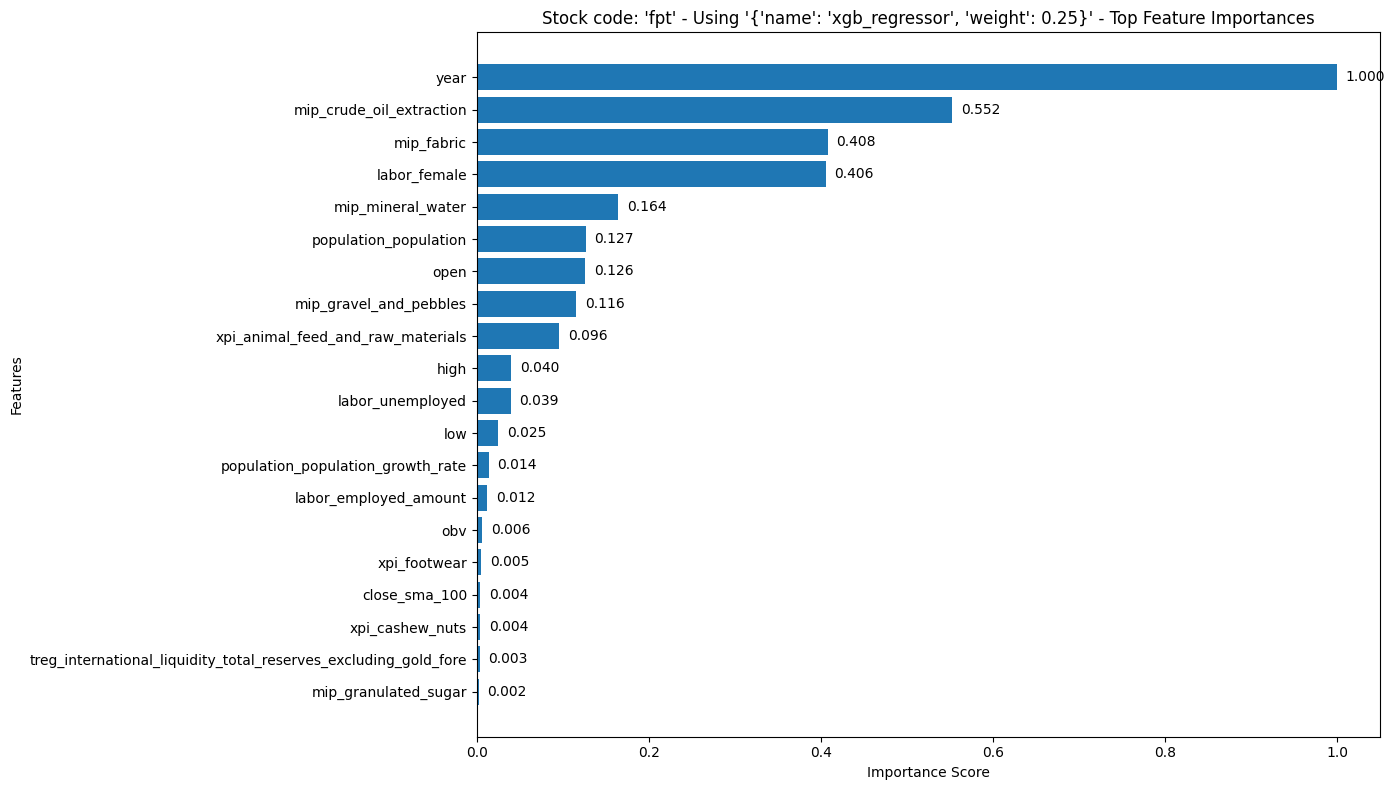

In [21]:
my_feature_selector.plot_feature_importance(FeatureSelectorType.XGB_REGRESSOR)

## Feature Selection Type: LASSO

In [22]:
my_feature_selector.get_feature_importance(FeatureSelectorType.LASSO)

,feature,importance
0,open,1.000000
1,high,0.160704
2,ado,0.009610
3,xpi_raw_plastics,0.002400
4,demand_osc_5_10,0.002109
...,...,...
329,mip_sawn_timber,0.000000
330,mip_sanitary_ware,0.000000
331,mip_rolled_steel_and_shaped_steel,0.000000
332,mip_refined_vegetable_oil,0.000000


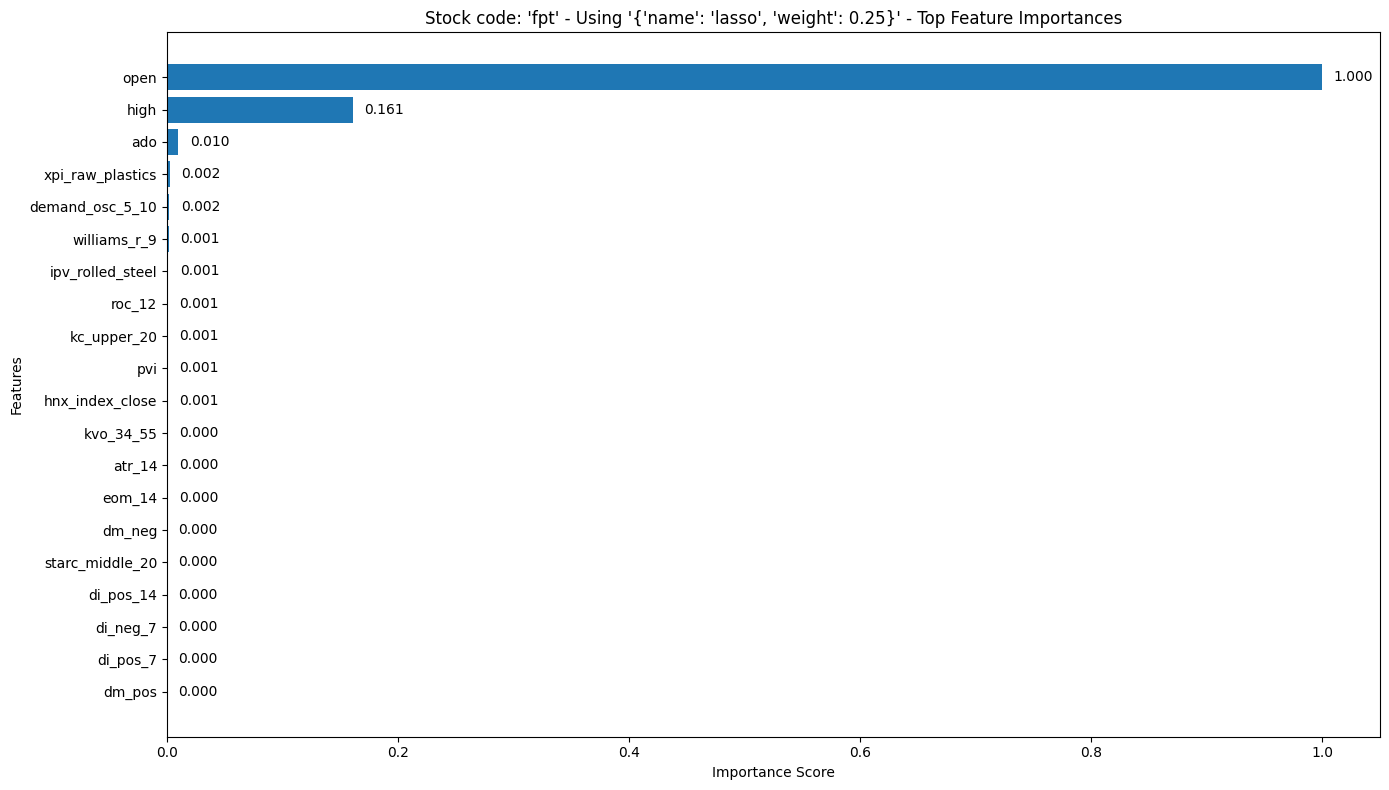

In [23]:
my_feature_selector.plot_feature_importance(FeatureSelectorType.LASSO)

## Feature Selection Type: ELASTIC_NET

In [24]:
my_feature_selector.get_feature_importance(FeatureSelectorType.ELASTIC_NET)

,feature,importance
0,dm_pos,1.000000
1,close_lwma_26,0.657949
2,close_lwma_12,0.620363
3,close_lwma_50,0.607715
4,low,0.590267
...,...,...
329,mip_sawn_timber,0.000000
330,mip_sanitary_ware,0.000000
331,mip_rolled_steel_and_shaped_steel,0.000000
332,mip_refined_vegetable_oil,0.000000


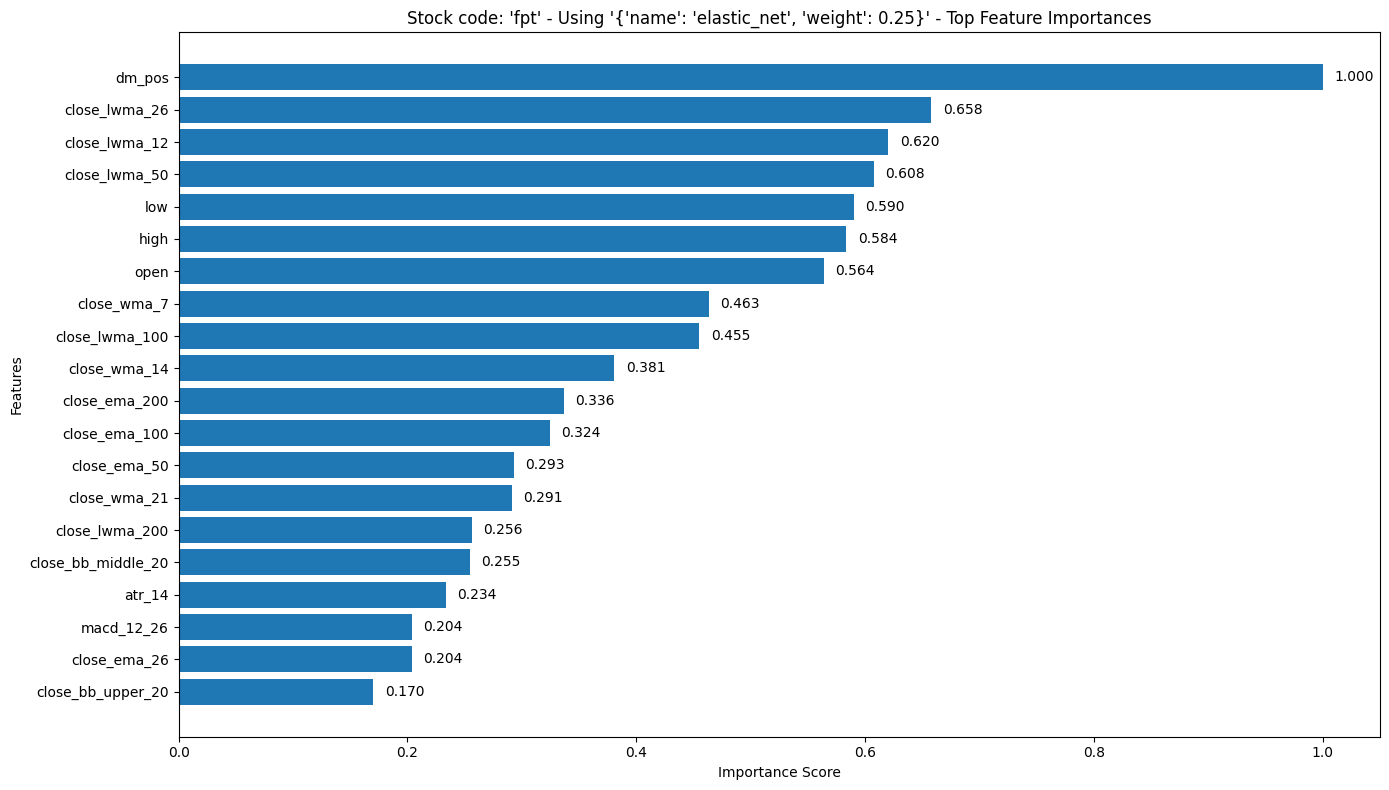

In [25]:
my_feature_selector.plot_feature_importance(FeatureSelectorType.ELASTIC_NET)

## Feature Selection Type: XGB_SHAP

In [26]:
my_feature_selector.get_feature_importance(FeatureSelectorType.XGB_SHAP)

,feature,importance
0,high,1.000000
1,low,0.729475
2,mip_fabric,0.442222
3,labor_female,0.272180
4,open,0.254577
...,...,...
329,adx_28,0.000000
330,di_pos_50,0.000000
331,oil_price_high,0.000000
332,oil_price_close,0.000000


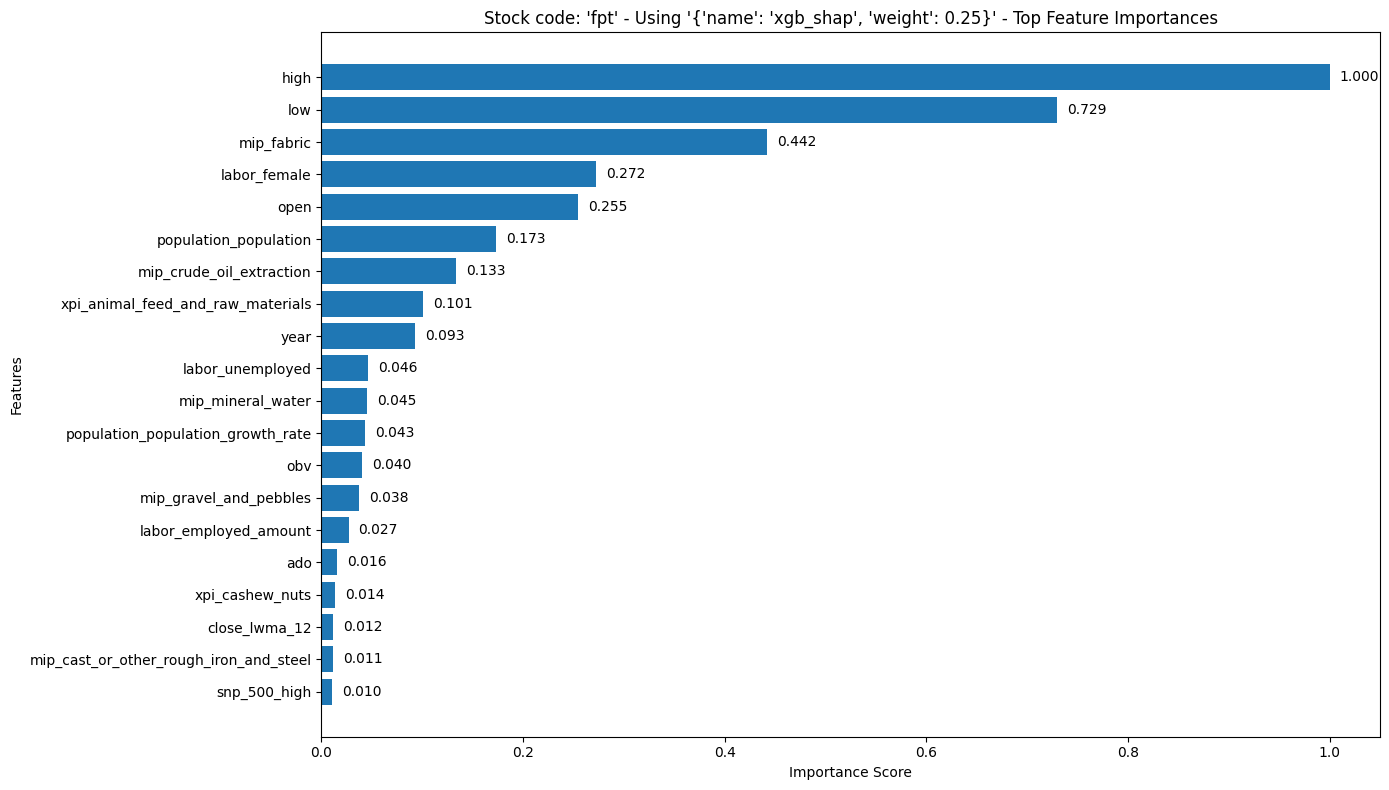

In [27]:
my_feature_selector.plot_feature_importance(FeatureSelectorType.XGB_SHAP)

## Summrarize Feature Importance

In [28]:
my_feature_selector.get_feature_importance()

,feature,xgb_regressor,lasso,elastic_net,xgb_shap,xgb_regressor_weighted,lasso_weighted,elastic_net_weighted,xgb_shap_weighted,final_importance
0,open,0.126138,1.000000,0.563685,0.254577,0.031534,0.250000,0.140921,0.063644,0.486100
1,high,0.040326,0.160704,0.583505,1.000000,0.010082,0.040176,0.145876,0.250000,0.446134
2,low,0.025144,0.000000,0.590267,0.729475,0.006286,0.000000,0.147567,0.182369,0.336222
3,year,1.000000,0.000000,0.000000,0.092764,0.250000,0.000000,0.000000,0.023191,0.273191
4,dm_pos,0.000181,0.000000,1.000000,0.000253,0.000045,0.000000,0.250000,0.000063,0.250109
...,...,...,...,...,...,...,...,...,...,...
329,day_of_year_sin,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
330,population_population_area_urban_rate,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
331,population_population_density,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
332,day_of_year,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


✅ Plot saved to: d:\GIT\master-thesis\logs\feature_selection\fpt_final_feature_importances.png


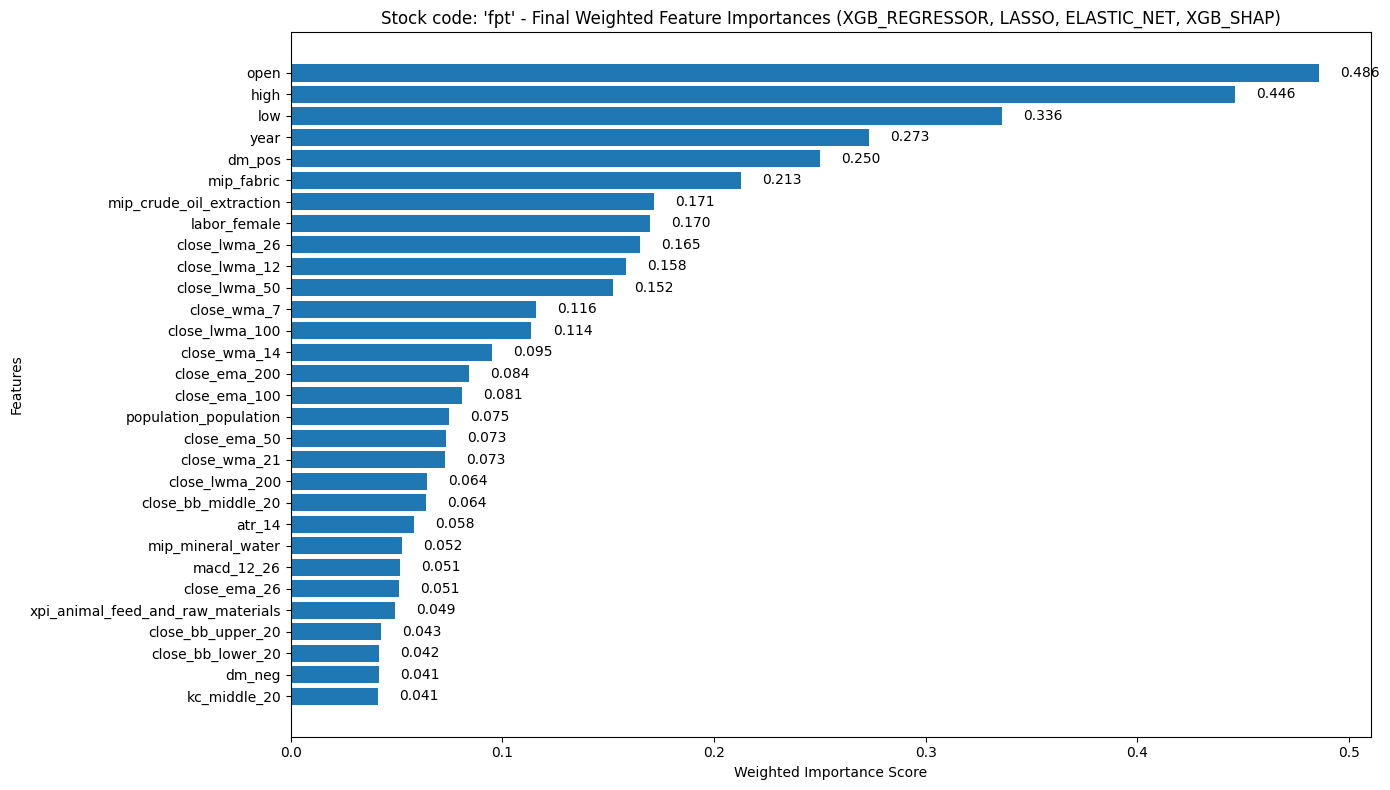

In [29]:
my_feature_selector.plot_final_feature_importances(
    stock_code=stock_code,
    filename=f"{stock_code}_final_feature_importances.png",
    top_n=30,
)

In [30]:
important_features_df = my_feature_selector.get_important_features_df(
    top_n=30,
)

In [31]:
important_features_df

,feature,final_importance
207,open,0.486100
76,high,0.446134
109,low,0.336222
333,year,0.273191
54,dm_pos,0.250109
133,mip_fabric,0.212597
130,mip_crude_oil_extraction,0.171477
103,labor_female,0.169537
20,close_lwma_26,0.164841
18,close_lwma_12,0.158421


In [32]:
important_features_list = important_features_df["feature"].tolist()
important_features_list

['open',
 'high',
 'low',
 'year',
 'dm_pos',
 'mip_fabric',
 'mip_crude_oil_extraction',
 'labor_female',
 'close_lwma_26',
 'close_lwma_12',
 'close_lwma_50',
 'close_wma_7',
 'close_lwma_100',
 'close_wma_14',
 'close_ema_200',
 'close_ema_100',
 'population_population',
 'close_ema_50',
 'close_wma_21',
 'close_lwma_200',
 'close_bb_middle_20',
 'atr_14',
 'mip_mineral_water',
 'macd_12_26',
 'close_ema_26',
 'xpi_animal_feed_and_raw_materials',
 'close_bb_upper_20',
 'close_bb_lower_20',
 'dm_neg',
 'kc_middle_20']

## Heatmap Visualization

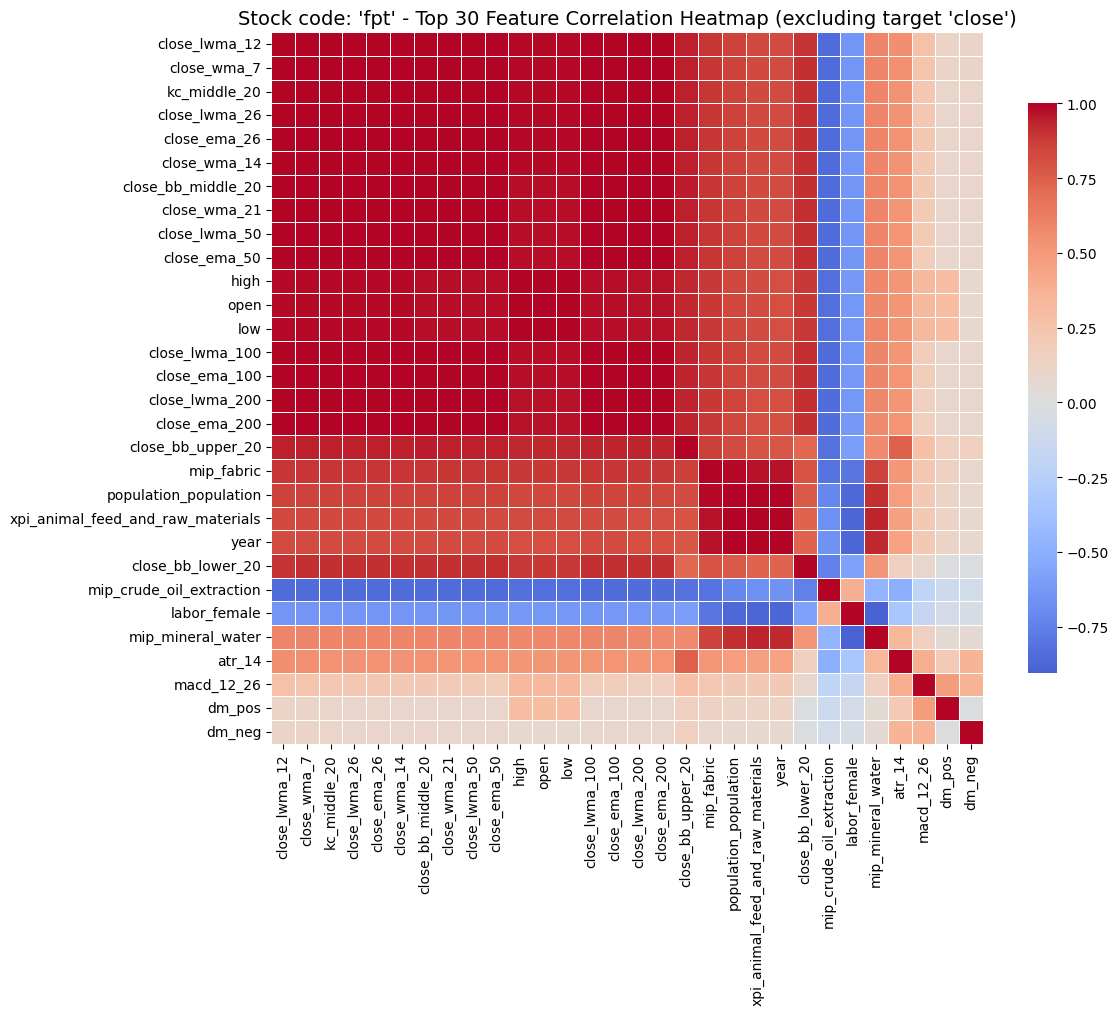

In [33]:
my_feature_selector.plot_feature_correlation_heatmap(
    stock_code=stock_code,
    importane_featrue_list=important_features_list,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

## Correlation DataFrame

In [34]:
correlation_df = my_feature_selector.get_feature_correlation_df(
    important_features_list=important_features_list,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

In [35]:
correlation_df

,feature_1,feature_2,corr
0,close_ema_26,close_wma_14,0.999999
1,close_wma_21,close_ema_50,0.999947
2,close_wma_21,close_lwma_50,0.999933
3,kc_middle_20,close_ema_26,0.999931
4,kc_middle_20,close_lwma_26,0.999928
...,...,...,...
208,close_lwma_100,population_population,0.851279
209,population_population,labor_female,-0.873566
210,year,labor_female,-0.879804
211,xpi_animal_feed_and_raw_materials,labor_female,-0.881294


In [36]:
kept_features, dropped_features, pruned_importance_df = (
    my_feature_selector.drop_low_importance_correlated_features(
        important_features_df=important_features_df,
        correlation_df=correlation_df,
        corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
    )
)

🔍 Dropped 23 highly correlated features (|r| >= 0.85):
['close_bb_lower_20', 'close_bb_middle_20', 'close_bb_upper_20', 'close_ema_100', 'close_ema_200', 'close_ema_26', 'close_ema_50', 'close_lwma_100', 'close_lwma_12', 'close_lwma_200', 'close_lwma_26', 'close_lwma_50', 'close_wma_14', 'close_wma_21', 'close_wma_7', 'high', 'kc_middle_20', 'labor_female', 'low', 'mip_fabric', 'mip_mineral_water', 'population_population', 'xpi_animal_feed_and_raw_materials']
✅ Kept 7 features after pruning correlation redundancy.


In [37]:
kept_features

['open',
 'year',
 'dm_pos',
 'mip_crude_oil_extraction',
 'atr_14',
 'macd_12_26',
 'dm_neg']

In [38]:
dropped_features

['close_bb_lower_20',
 'close_bb_middle_20',
 'close_bb_upper_20',
 'close_ema_100',
 'close_ema_200',
 'close_ema_26',
 'close_ema_50',
 'close_lwma_100',
 'close_lwma_12',
 'close_lwma_200',
 'close_lwma_26',
 'close_lwma_50',
 'close_wma_14',
 'close_wma_21',
 'close_wma_7',
 'high',
 'kc_middle_20',
 'labor_female',
 'low',
 'mip_fabric',
 'mip_mineral_water',
 'population_population',
 'xpi_animal_feed_and_raw_materials']

In [39]:
print(f"Dropped: {len(dropped_features)} features")

Dropped: 23 features


In [40]:
feature_selected_train = train.drop(columns=dropped_features)
feature_selected_train

,gdp_gdp_growth,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,xpi_confectionery_and_cereal_products,...,eom_20,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10
0,7.562049,2406.138387,115.831987,97.292581,20.176133,28.639014,13.919893,597.898599,939.485161,21.957834,...,0.063974,0.013752,1.572394e+03,705.695191,-0.144824,-0.155760,0.010936,2089.084721,1435.104345,-46651.229284
1,7.561311,2417.355484,115.912763,97.763226,20.190203,28.658985,13.929600,598.315544,940.726452,21.973146,...,0.049712,0.007764,1.497772e+03,705.695191,-0.140902,-0.152788,0.011886,1647.136005,1465.394582,-84138.628711
2,7.559098,2451.006774,116.155089,99.175161,20.232413,28.718900,13.958721,599.566378,944.450323,22.019083,...,0.045432,0.004934,1.497772e+03,693.034370,-0.136974,-0.149626,0.012651,1301.166457,1441.933421,-89210.966379
3,7.558361,2462.223871,116.235864,99.645806,20.246483,28.738871,13.968428,599.983322,945.691613,22.034396,...,0.056099,0.007278,1.497772e+03,725.918651,-0.132675,-0.146235,0.013560,1428.415956,1440.002355,-36784.961064
4,7.557623,2473.440968,116.316640,100.116452,20.260552,28.758842,13.978135,600.400267,946.932903,22.049708,...,0.063313,0.016438,1.497772e+03,725.918651,-0.128074,-0.142603,0.014529,1341.339431,1425.907652,-18331.361208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3775,4.722065,790.967742,490.322581,53.645161,200.000000,165.161290,226.774194,2932.258065,84.516129,110.661971,...,0.091713,0.218405,3.260996e+07,0.187735,0.076655,0.076347,0.000308,-1122.249022,263.243876,52530.588075
3776,4.735000,790.322581,496.774194,53.548387,200.000000,168.387097,227.258065,2927.419355,84.838710,110.677283,...,0.115135,0.225604,3.316270e+07,0.187735,0.076981,0.076474,0.000507,-7.134362,224.618414,66581.223420
3777,4.747935,789.677419,503.225806,53.451613,200.000000,171.612903,227.741935,2922.580645,85.161290,110.692596,...,0.140758,0.242073,3.359693e+07,0.187735,0.078449,0.076869,0.001580,1115.046794,351.822468,183416.260432
3778,4.760870,789.032258,509.677419,53.354839,200.000000,174.838710,228.225806,2917.741935,85.483871,110.707908,...,0.128611,0.254161,3.395225e+07,0.187735,0.081727,0.077841,0.003886,2834.540965,706.496539,575804.853708


## Heatmap Visualization before + after feature selection

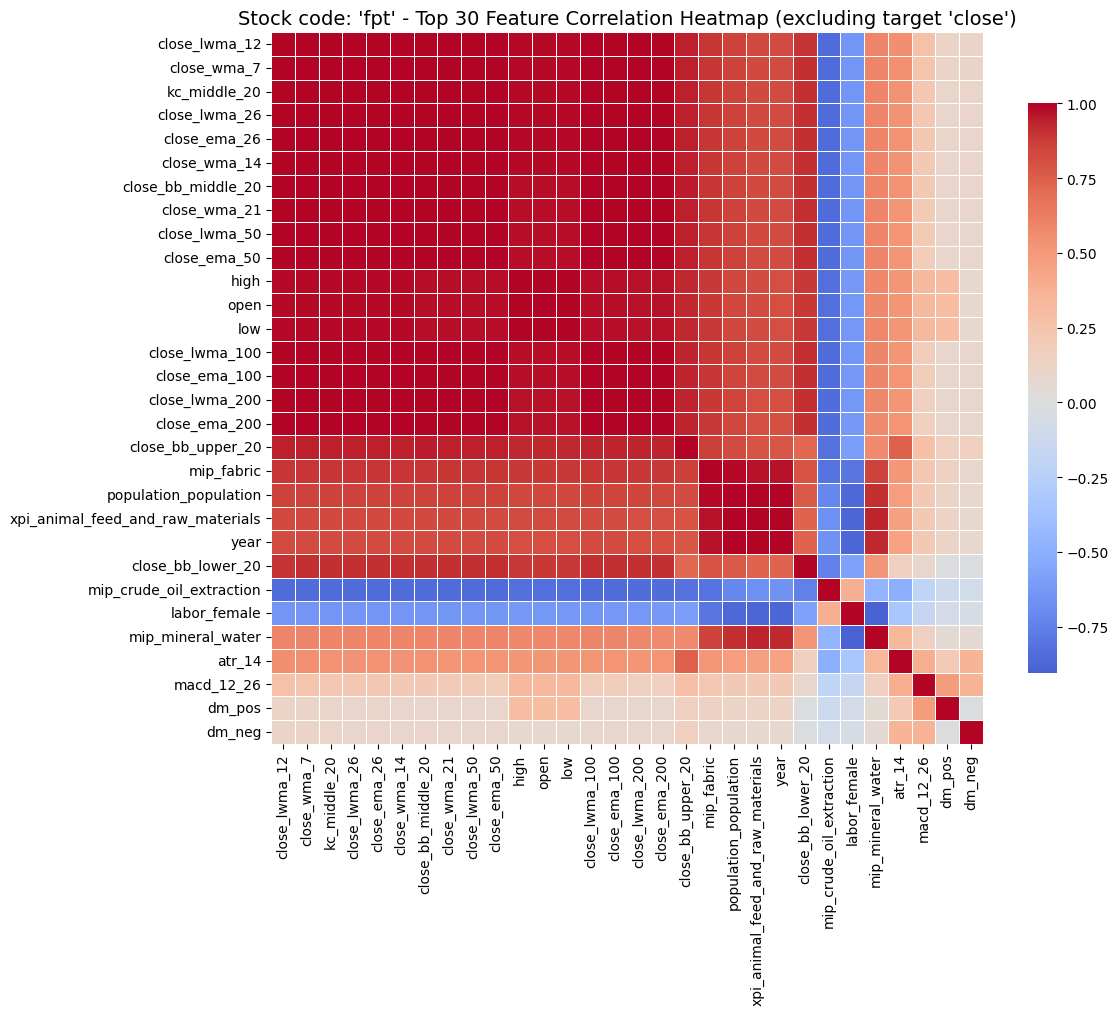

In [41]:
my_feature_selector.plot_feature_correlation_heatmap(
    stock_code=stock_code,
    importane_featrue_list=important_features_list,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

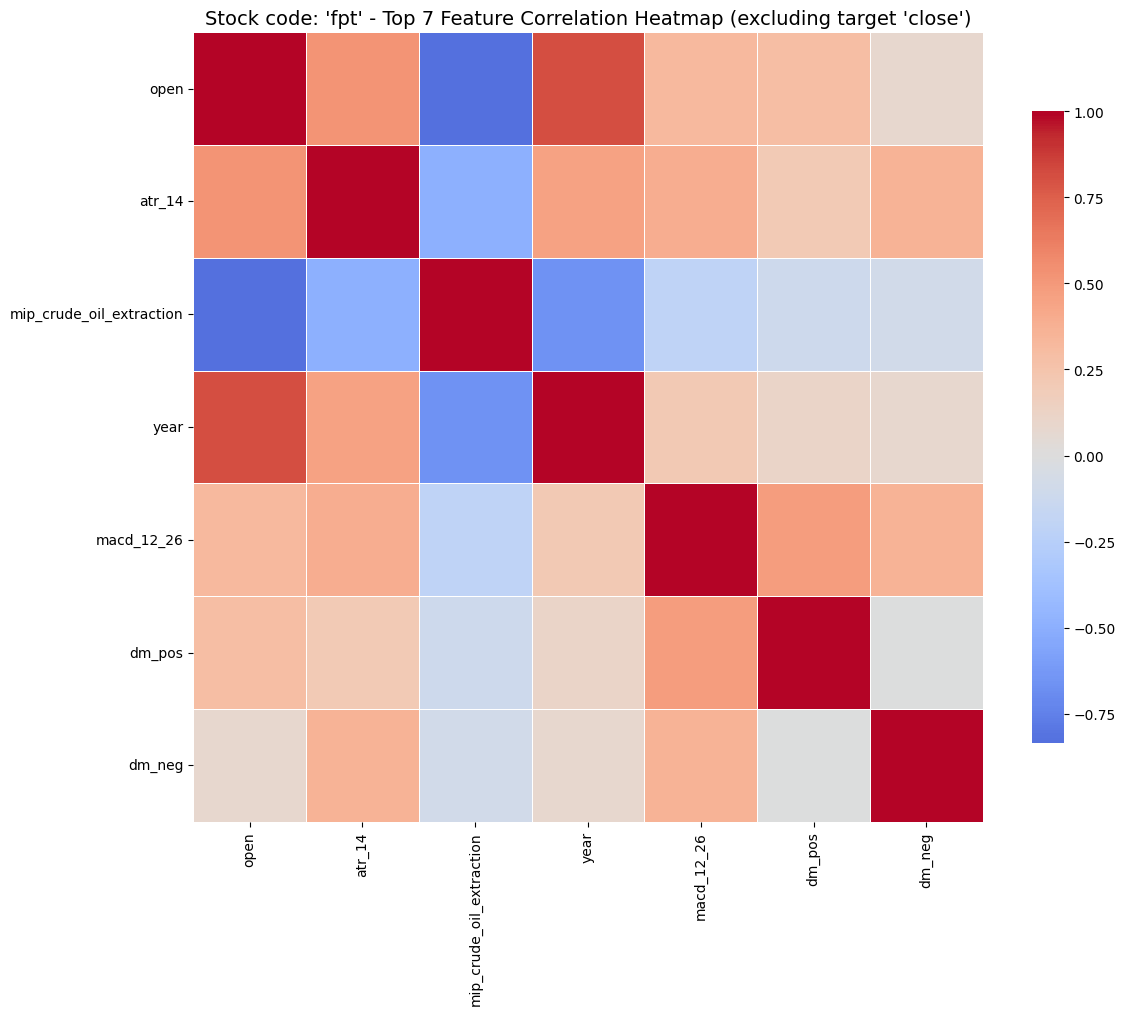

In [42]:
my_feature_selector.plot_feature_correlation_heatmap(
    stock_code=stock_code,
    importane_featrue_list=kept_features,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

## Feature Selected train dataframe

In [43]:
feature_selected_train

,gdp_gdp_growth,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,xpi_confectionery_and_cereal_products,...,eom_20,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10
0,7.562049,2406.138387,115.831987,97.292581,20.176133,28.639014,13.919893,597.898599,939.485161,21.957834,...,0.063974,0.013752,1.572394e+03,705.695191,-0.144824,-0.155760,0.010936,2089.084721,1435.104345,-46651.229284
1,7.561311,2417.355484,115.912763,97.763226,20.190203,28.658985,13.929600,598.315544,940.726452,21.973146,...,0.049712,0.007764,1.497772e+03,705.695191,-0.140902,-0.152788,0.011886,1647.136005,1465.394582,-84138.628711
2,7.559098,2451.006774,116.155089,99.175161,20.232413,28.718900,13.958721,599.566378,944.450323,22.019083,...,0.045432,0.004934,1.497772e+03,693.034370,-0.136974,-0.149626,0.012651,1301.166457,1441.933421,-89210.966379
3,7.558361,2462.223871,116.235864,99.645806,20.246483,28.738871,13.968428,599.983322,945.691613,22.034396,...,0.056099,0.007278,1.497772e+03,725.918651,-0.132675,-0.146235,0.013560,1428.415956,1440.002355,-36784.961064
4,7.557623,2473.440968,116.316640,100.116452,20.260552,28.758842,13.978135,600.400267,946.932903,22.049708,...,0.063313,0.016438,1.497772e+03,725.918651,-0.128074,-0.142603,0.014529,1341.339431,1425.907652,-18331.361208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3775,4.722065,790.967742,490.322581,53.645161,200.000000,165.161290,226.774194,2932.258065,84.516129,110.661971,...,0.091713,0.218405,3.260996e+07,0.187735,0.076655,0.076347,0.000308,-1122.249022,263.243876,52530.588075
3776,4.735000,790.322581,496.774194,53.548387,200.000000,168.387097,227.258065,2927.419355,84.838710,110.677283,...,0.115135,0.225604,3.316270e+07,0.187735,0.076981,0.076474,0.000507,-7.134362,224.618414,66581.223420
3777,4.747935,789.677419,503.225806,53.451613,200.000000,171.612903,227.741935,2922.580645,85.161290,110.692596,...,0.140758,0.242073,3.359693e+07,0.187735,0.078449,0.076869,0.001580,1115.046794,351.822468,183416.260432
3778,4.760870,789.032258,509.677419,53.354839,200.000000,174.838710,228.225806,2917.741935,85.483871,110.707908,...,0.128611,0.254161,3.395225e+07,0.187735,0.081727,0.077841,0.003886,2834.540965,706.496539,575804.853708
